# Notebook Demonstrativo — `cProfile` e `snakeviz`

Este notebook foi pensado para ensinar, de forma prática e didática, como usar duas ferramentas clássicas de análise de desempenho em Python:

- **`cProfile`** → profiler embutido na biblioteca padrão;
- **`snakeviz`** → visualizador interativo para arquivos de profiling.

## Objetivos
Ao final deste notebook, o aluno deve ser capaz de:

1. entender o que é profiling;
2. instrumentar um código com `cProfile`;
3. salvar um arquivo `.prof`;
4. ler estatísticas com `pstats`;
5. abrir e interpretar o resultado no `snakeviz`;
6. distinguir:
   - tempo total;
   - tempo acumulado;
   - hotspots;
   - chamadas frequentes.

## Ideia central
Vamos usar um pipeline pequeno, mas propositalmente imperfeito, para produzir gargalos visíveis.

> Regra de ouro da aula: **não otimizar antes de medir**.


## 1. O que é profiling?

**Profiling** é a medição do comportamento de um programa em execução.

Ele nos ajuda a responder perguntas como:

- Qual função consome mais tempo?
- Quantas vezes uma função foi chamada?
- O gargalo está em cálculo, I/O ou excesso de chamadas?
- O problema está na função errada que eu imaginava?

### Duas ferramentas, dois papéis
- **`cProfile`**: coleta os dados de execução;
- **`snakeviz`**: ajuda a visualizar esses dados de forma interativa.

### Fluxo que vamos seguir
```text
Executar código -> coletar perfil -> salvar .prof -> inspecionar tabela -> abrir no snakeviz
```


In [1]:

from __future__ import annotations

import os
import io
import time
import math
import random
import pstats
import cProfile
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = str

RNG = np.random.default_rng(42)
random.seed(42)

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

PROFILE_DIR = Path("./profiles_demo")
PROFILE_DIR.mkdir(parents=True, exist_ok=True)

print("Diretório de perfis:", PROFILE_DIR.resolve())


Diretório de perfis: /mnt/c/Users/chaul.NK/Dropbox/_FATESG/CP/M3A2/profiles_demo


## 2. Um pipeline simples e propositalmente imperfeito

Vamos criar um mini pipeline com três etapas:

1. **geração dos dados**
2. **transformação pesada**
3. **extração de estatísticas**

Ele terá alguns problemas intencionais:

- loops Python desnecessários;
- repetição de trabalho;
- mistura de operações vetorizadas e não vetorizadas.

Isso é ótimo para fins didáticos, porque gera hotspots claros.


In [2]:

def generate_batches(n_batches: int = 40, batch_size: int = 300, dim: int = 64) -> list[np.ndarray]:
    batches = []
    for _ in range(n_batches):
        arr = RNG.normal(0, 1, size=(batch_size, dim)).astype(np.float64)
        batches.append(arr)
    return batches

def heavy_transform(batch: np.ndarray, rounds: int = 4) -> np.ndarray:
    x = batch.copy()
    for _ in range(rounds):
        x = np.tanh(x)
        x = np.sqrt(np.abs(x) + 1e-8)
        x = np.sin(x) + np.cos(x)
    return x

def slow_histogram_python(vec: np.ndarray, bins: int = 32) -> np.ndarray:
    hist = np.zeros(bins, dtype=np.float64)
    for value in vec:
        idx = min(int(abs(value) * (bins - 1)) % bins, bins - 1)
        hist[idx] += 1.0
    hist /= hist.sum() + 1e-8
    return hist

def extract_features_slow(batch: np.ndarray) -> np.ndarray:
    features = []
    for row in batch:
        hist = slow_histogram_python(row, bins=32)
        mean = row.mean()
        std = row.std()
        mx = row.max()
        mn = row.min()
        features.append(np.concatenate([hist, [mean, std, mx, mn]]))
    return np.vstack(features)

def toy_pipeline(n_batches: int = 40, batch_size: int = 300, dim: int = 64) -> pd.DataFrame:
    batches = generate_batches(n_batches=n_batches, batch_size=batch_size, dim=dim)

    rows = []
    for i, batch in enumerate(batches):
        t0 = time.perf_counter()
        transformed = heavy_transform(batch, rounds=4)
        feats = extract_features_slow(transformed)
        elapsed = time.perf_counter() - t0

        rows.append({
            "batch_id": i,
            "rows": batch.shape[0],
            "cols": batch.shape[1],
            "elapsed_s": elapsed,
            "feature_dim": feats.shape[1]
        })
    return pd.DataFrame(rows)


## 3. Execução normal do pipeline

Antes de fazer profiling, vamos apenas executar o código e observar o tempo total.


In [3]:

t0 = time.perf_counter()
df_result = toy_pipeline(n_batches=20, batch_size=250, dim=64)
baseline_time = time.perf_counter() - t0

print(f"Tempo total sem profiling explícito: {baseline_time:.3f} s")
display(df_result.head())
display(df_result.describe())


Tempo total sem profiling explícito: 0.206 s


,batch_id,rows,cols,elapsed_s,feature_dim
0,0,250,64,0.010964,36
1,1,250,64,0.009966,36
2,2,250,64,0.010638,36
3,3,250,64,0.010690,36
4,4,250,64,0.009287,36


,batch_id,rows,cols,elapsed_s,feature_dim
count,20.00000,20.0,20.0,20.000000,20.0
mean,9.50000,250.0,64.0,0.010012,36.0
std,5.91608,0.0,0.0,0.000632,0.0
min,0.00000,250.0,64.0,0.009211,36.0
25%,4.75000,250.0,64.0,0.009432,36.0
50%,9.50000,250.0,64.0,0.009946,36.0
75%,14.25000,250.0,64.0,0.010387,36.0
max,19.00000,250.0,64.0,0.011309,36.0


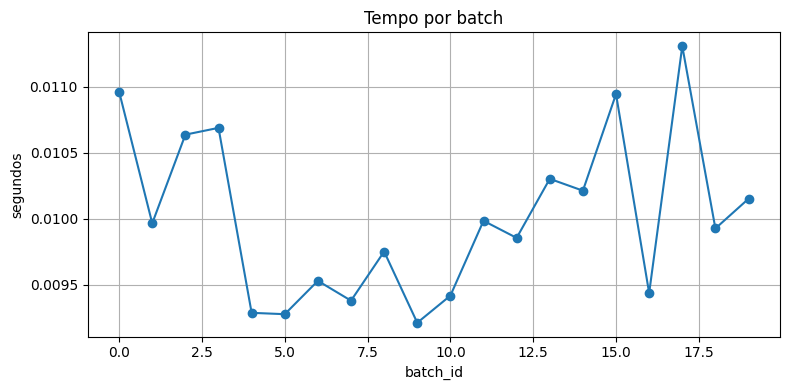

In [4]:

ax = df_result.plot(x="batch_id", y="elapsed_s", marker="o", legend=False, title="Tempo por batch")
ax.set_ylabel("segundos")
plt.tight_layout()
plt.show()


## 4. Primeiro contato com `cProfile`

A forma mais direta de usar `cProfile` em notebook é:

1. criar um objeto `Profile()`;
2. dar `enable()`;
3. executar o trecho de interesse;
4. dar `disable()`;
5. inspecionar com `pstats`.

### Observação importante
Você deve perfilar **o trecho relevante**, não o notebook inteiro.


In [5]:

prof = cProfile.Profile()

prof.enable()
_ = toy_pipeline(n_batches=20, batch_size=250, dim=64)
prof.disable()

print("Profiling concluído.")


Profiling concluído.


## 5. Lendo as estatísticas com `pstats`

Vamos ordenar por **tempo acumulado** (`cumulative`), que costuma ser ótimo para localizar gargalos em cadeias de chamadas.

### Colunas importantes
- **ncalls**: número de chamadas
- **tottime**: tempo gasto só naquela função
- **cumtime**: tempo acumulado incluindo chamadas internas

### Dica didática
- `tottime` ajuda a localizar funções que são gargalo direto;
- `cumtime` ajuda a localizar funções “raiz” do custo.


In [6]:

stats = pstats.Stats(prof).sort_stats("cumulative")
stats.print_stats(20)


         846014 function calls (846005 primitive calls) in 0.368 seconds

   Ordered by: cumulative time
   List reduced from 164 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    0.368    0.184 /home/chaul/hpc_gpu/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3543(run_code)
        2    0.000    0.000    0.368    0.184 {built-in method builtins.exec}
        1    0.000    0.000    0.368    0.368 /tmp/ipykernel_1503/1738048286.py:1(<module>)
        1    0.001    0.001    0.368    0.368 /tmp/ipykernel_1503/225758290.py:35(toy_pipeline)
       20    0.019    0.001    0.336    0.017 /tmp/ipykernel_1503/225758290.py:24(extract_features_slow)
     5000    0.147    0.000    0.206    0.000 /tmp/ipykernel_1503/225758290.py:16(slow_histogram_python)
     5000    0.002    0.000    0.063    0.000 {method 'std' of 'numpy.ndarray' objects}
     5000    0.008    0.000    0.062    0.000 /home/chaul/hp

## 6. Salvando o perfil em arquivo `.prof`

Essa etapa é essencial para usar o `snakeviz`.


In [7]:

profile_path = PROFILE_DIR / "toy_pipeline.prof"
prof.dump_stats(str(profile_path))

print("Arquivo salvo em:")
print(profile_path.resolve())


Arquivo salvo em:
/mnt/c/Users/chaul.NK/Dropbox/_FATESG/CP/M3A2/profiles_demo/toy_pipeline.prof


## 7. Filtrando e reorganizando estatísticas

Você também pode explorar os dados do perfil programaticamente.

Aqui estão alguns exemplos úteis para a aula.


In [8]:

print("Top 15 por tempo acumulado")
stats = pstats.Stats(str(profile_path)).sort_stats("cumulative")
stats.print_stats(15)

print("\nTop 15 por tempo próprio (tottime)")
stats = pstats.Stats(str(profile_path)).sort_stats("tottime")
stats.print_stats(15)


Top 15 por tempo acumulado
Sun Apr  5 19:10:25 2026    profiles_demo/toy_pipeline.prof

         846014 function calls (846005 primitive calls) in 0.368 seconds

   Ordered by: cumulative time
   List reduced from 164 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    0.368    0.184 /home/chaul/hpc_gpu/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3543(run_code)
        2    0.000    0.000    0.368    0.184 {built-in method builtins.exec}
        1    0.000    0.000    0.368    0.368 /tmp/ipykernel_1503/1738048286.py:1(<module>)
        1    0.001    0.001    0.368    0.368 /tmp/ipykernel_1503/225758290.py:35(toy_pipeline)
       20    0.019    0.001    0.336    0.017 /tmp/ipykernel_1503/225758290.py:24(extract_features_slow)
     5000    0.147    0.000    0.206    0.000 /tmp/ipykernel_1503/225758290.py:16(slow_histogram_python)
     5000    0.002    0.000    0.063    0.000 {method 'std' 

## 8. Interpretando o resultado

Ao olhar a saída do `cProfile`, tente responder:

1. A maior parte do tempo está em qual função?
2. Essa função é chamada muitas vezes ou poucas vezes?
3. O gargalo é um loop Python?
4. Há uma função “pai” com grande tempo acumulado?

### Leitura esperada neste notebook
Normalmente, o hotspot principal aparece em:
- `extract_features_slow`
- `slow_histogram_python`

Isso é ótimo, porque mostra um caso clássico de gargalo em Python puro.


## 9. Gerando uma versão melhorada para comparação

Vamos agora construir uma versão otimizada localmente, trocando o histograma em loop Python por uma versão vetorizada com NumPy.

Isso é útil para mostrar que profiling não serve apenas para “achar problemas”, mas para **validar melhorias**.


In [9]:

def fast_histogram_numpy(vec: np.ndarray, bins: int = 32) -> np.ndarray:
    hist, _ = np.histogram(np.abs(vec), bins=bins, range=(0.0, np.abs(vec).max() + 1e-8))
    hist = hist.astype(np.float64)
    hist /= hist.sum() + 1e-8
    return hist

def extract_features_fast(batch: np.ndarray) -> np.ndarray:
    features = []
    for row in batch:
        hist = fast_histogram_numpy(row, bins=32)
        mean = row.mean()
        std = row.std()
        mx = row.max()
        mn = row.min()
        features.append(np.concatenate([hist, [mean, std, mx, mn]]))
    return np.vstack(features)

def toy_pipeline_fast(n_batches: int = 40, batch_size: int = 300, dim: int = 64) -> pd.DataFrame:
    batches = generate_batches(n_batches=n_batches, batch_size=batch_size, dim=dim)

    rows = []
    for i, batch in enumerate(batches):
        t0 = time.perf_counter()
        transformed = heavy_transform(batch, rounds=4)
        feats = extract_features_fast(transformed)
        elapsed = time.perf_counter() - t0

        rows.append({
            "batch_id": i,
            "rows": batch.shape[0],
            "cols": batch.shape[1],
            "elapsed_s": elapsed,
            "feature_dim": feats.shape[1]
        })
    return pd.DataFrame(rows)


In [10]:

t0 = time.perf_counter()
_ = toy_pipeline_fast(n_batches=20, batch_size=250, dim=64)
fast_time = time.perf_counter() - t0

comparison = pd.DataFrame({
    "versao": ["lenta", "melhorada"],
    "tempo_total_s": [baseline_time, fast_time]
})
comparison["speedup"] = baseline_time / comparison["tempo_total_s"]

display(comparison)


,versao,tempo_total_s,speedup
0,lenta,0.206455,1.00000
1,melhorada,0.304654,0.67767


## 10. Profiling da versão melhorada

Agora vamos repetir o processo e salvar outro arquivo de perfil.


In [11]:

prof_fast = cProfile.Profile()

prof_fast.enable()
_ = toy_pipeline_fast(n_batches=20, batch_size=250, dim=64)
prof_fast.disable()

profile_fast_path = PROFILE_DIR / "toy_pipeline_fast.prof"
prof_fast.dump_stats(str(profile_fast_path))

print("Perfis disponíveis:")
for p in PROFILE_DIR.glob("*.prof"):
    print("-", p.name)


Perfis disponíveis:
- toy_pipeline.prof
- toy_pipeline_fast.prof


In [12]:

print("Versão melhorada — top por tempo acumulado")
stats_fast = pstats.Stats(str(profile_fast_path)).sort_stats("cumulative")
stats_fast.print_stats(15)


Versão melhorada — top por tempo acumulado
Sun Apr  5 19:10:26 2026    profiles_demo/toy_pipeline_fast.prof

         496014 function calls (496005 primitive calls) in 0.437 seconds

   Ordered by: cumulative time
   List reduced from 187 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    0.437    0.219 /home/chaul/hpc_gpu/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3543(run_code)
        2    0.000    0.000    0.437    0.219 {built-in method builtins.exec}
        1    0.000    0.000    0.437    0.437 /tmp/ipykernel_1503/2858362659.py:1(<module>)
        1    0.001    0.001    0.437    0.437 /tmp/ipykernel_1503/1200927221.py:18(toy_pipeline_fast)
       20    0.020    0.001    0.410    0.021 /tmp/ipykernel_1503/1200927221.py:7(extract_features_fast)
     5000    0.018    0.000    0.278    0.000 /tmp/ipykernel_1503/1200927221.py:1(fast_histogram_numpy)
     5000    0.075    0.000    0.2

## 11. O que é `snakeviz`?

`snakeviz` é uma ferramenta que lê arquivos `.prof` gerados pelo `cProfile` e abre uma visualização interativa no navegador.

Ela costuma mostrar os resultados em dois formatos principais:
- **sunburst**
- **icicle**

### Por que isso é útil?
Porque tabelas de texto são boas para precisão, mas visualizações são melhores para:
- perceber proporções;
- navegar pela árvore de chamadas;
- identificar rapidamente a relação entre função pai e função filha.


## 12. Instalando o `snakeviz`

Em muitos ambientes, basta executar:

```bash
pip install snakeviz
```

Se você estiver em um ambiente com `conda`, também pode usar:

```bash
conda install -c conda-forge snakeviz
```

> Execute apenas se necessário.


In [13]:

# Descomente se precisar instalar no ambiente atual:
# !pip install snakeviz
print("Instalação via notebook deixada comentada para evitar mudanças automáticas no ambiente.")


Instalação via notebook deixada comentada para evitar mudanças automáticas no ambiente.


## 13. Como abrir o `snakeviz`

### Opção 1 — pelo terminal
Abra um terminal no mesmo diretório do notebook e rode:

```bash
snakeviz profiles_demo/toy_pipeline.prof
```

ou, para a versão melhorada:

```bash
snakeviz profiles_demo/toy_pipeline_fast.prof
```

### Opção 2 — chamando pelo Python
Em alguns ambientes, isso também funciona.


In [14]:

def check_snakeviz():
    try:
        result = subprocess.run(["snakeviz", "--version"], capture_output=True, text=True, check=False)
        return result.returncode == 0, result.stdout.strip() or result.stderr.strip()
    except FileNotFoundError:
        return False, "snakeviz não encontrado no PATH."

ok, msg = check_snakeviz()
print("snakeviz disponível?", ok)
print(msg)


snakeviz disponível? True
snakeviz 2.2.2


In [15]:

print("Exemplo de comando que você deve executar no terminal:")
print(f"snakeviz {profile_path}")
print(f"snakeviz {profile_fast_path}")


Exemplo de comando que você deve executar no terminal:
snakeviz profiles_demo/toy_pipeline.prof
snakeviz profiles_demo/toy_pipeline_fast.prof


## 14. Como interpretar o `snakeviz`

Quando abrir o arquivo `.prof`, peça aos alunos para observar:

### No gráfico
- qual bloco ocupa maior área;
- quais funções estão “dentro” desse bloco;
- se o custo está concentrado em uma função ou espalhado em várias.

### Na navegação
- clique na função dominante;
- observe quem chama essa função;
- observe quem é chamado por ela.

### Perguntas para guiar a leitura
1. O hotspot é de fato a função que eu esperava?
2. O problema está no volume de chamadas ou no custo por chamada?
3. A melhoria feita mudou o hotspot ou apenas deslocou o gargalo?


## 15. Tabela-resumo: `cProfile` vs `snakeviz`

| Ferramenta | Papel principal | Melhor uso |
|---|---|---|
| `cProfile` | coletar perfil e exibir tabelas | inspeção inicial e precisa |
| `pstats` | ordenar e filtrar estatísticas | leitura analítica em texto |
| `snakeviz` | explorar visualmente a árvore de chamadas | ensino, navegação e interpretação |

### Regra prática
Use:
1. `cProfile` para gerar o perfil;
2. `pstats` para leitura rápida e objetiva;
3. `snakeviz` para análise visual aprofundada.


## 16. Exercício guiado para os alunos

### Parte A — coletar perfil
1. Rode o pipeline lento com `cProfile`.
2. Salve o arquivo `.prof`.
3. Mostre os 10 maiores por `cumulative`.

### Parte B — investigar
4. Identifique a função hotspot.
5. Explique por que ela é cara.

### Parte C — melhorar
6. Troque uma função lenta por uma versão vetorizada.
7. Gere novo `.prof`.
8. Compare os dois resultados.

### Parte D — visualizar
9. Abra os dois perfis no `snakeviz`.
10. Escreva um pequeno parágrafo dizendo o que mudou.


## 17. Desafios extras

1. Aumentar `n_batches` e observar como o perfil muda.
2. Aumentar `batch_size` e ver se o hotspot permanece o mesmo.
3. Trocar o custo de `heavy_transform` e observar se o gargalo migra.
4. Criar uma terceira versão “meio otimizada” e comparar com as outras duas.
5. Tentar perfilar apenas uma função específica e comparar com o pipeline inteiro.

> Ideia central: profiling é uma ferramenta de diagnóstico e validação, não um ritual.


In [16]:

# Célula livre para experimentos
# Sugestão: gerar um terceiro arquivo .prof com outra variação do pipeline.
pass
